# 10MB

## download dataset

In [1]:
import os
from datasets import load_dataset

BASE_DIR = r"D:\Hand_Gesture"

HF_HOME = os.path.join(BASE_DIR, "data", "raw", "hf_home")
HF_CACHE = os.path.join(BASE_DIR, "data", "raw", "hf_cache")

os.makedirs(HF_HOME, exist_ok=True)
os.makedirs(HF_CACHE, exist_ok=True)

os.environ["HF_HOME"] = HF_HOME
os.environ["HF_DATASETS_CACHE"] = HF_CACHE

dataset = load_dataset(
    "testdummyvt/hagRIDv2_512px_10GB",
    split="train",
    revision="classification",
    cache_dir=HF_CACHE,
)

print(dataset)
print(dataset.features)

sample = dataset[0]
print(sample.keys())

if "image" in sample:
    print("image size:", sample["image"].size)

if "label" in sample:
    print("label:", sample["label"])
    if hasattr(dataset.features["label"], "names"):
        print("label name:", dataset.features["label"].names[sample["label"]])

c:\Users\user\anaconda3\envs\handgesture\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset({
    features: ['image', 'label', 'file_name'],
    num_rows: 83964
})
{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['call', 'dislike', 'fist', 'four', 'grabbing', 'grip', 'hand_heart', 'hand_heart2', 'holy', 'like', 'little_finger', 'middle_finger', 'mute', 'no_gesture', 'ok', 'one', 'palm', 'peace', 'peace_inverted', 'point', 'rock', 'stop', 'stop_inverted', 'take_picture', 'three', 'three2', 'three3', 'three_gun', 'thumb_index', 'thumb_index2', 'timeout', 'two_up', 'two_up_inverted', 'xsign']), 'file_name': Value('string')}
dict_keys(['image', 'label', 'file_name'])
image size: (512, 683)
label: 0
label name: call


In [2]:
from datasets import load_dataset

dataset = load_dataset(
    "testdummyvt/hagRIDv2_512px_10GB",
    split="train",
    revision="classification",
    cache_dir="D:/Hand_Gesture/data/raw/hf_cache"
)

print(dataset)
print(dataset.features)
print(dataset[0].keys())

Dataset({
    features: ['image', 'label', 'file_name'],
    num_rows: 83964
})
{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['call', 'dislike', 'fist', 'four', 'grabbing', 'grip', 'hand_heart', 'hand_heart2', 'holy', 'like', 'little_finger', 'middle_finger', 'mute', 'no_gesture', 'ok', 'one', 'palm', 'peace', 'peace_inverted', 'point', 'rock', 'stop', 'stop_inverted', 'take_picture', 'three', 'three2', 'three3', 'three_gun', 'thumb_index', 'thumb_index2', 'timeout', 'two_up', 'two_up_inverted', 'xsign']), 'file_name': Value('string')}
dict_keys(['image', 'label', 'file_name'])


## check labels

In [3]:
from datasets import load_dataset
from collections import Counter

dataset = load_dataset(
    "testdummyvt/hagRIDv2_512px_10GB",
    split="train",
    revision="classification",
    cache_dir="D:/Hand_Gesture/data/raw/hf_cache"
)

print(dataset)
print(dataset.features)

label_names = dataset.features["label"].names
print("\nLabel names:")
for i, name in enumerate(label_names):
    print(i, name)

counts = Counter(dataset["label"])

print("\nClass counts:")
for idx, count in sorted(counts.items()):
    print(idx, label_names[idx], count)

Dataset({
    features: ['image', 'label', 'file_name'],
    num_rows: 83964
})
{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['call', 'dislike', 'fist', 'four', 'grabbing', 'grip', 'hand_heart', 'hand_heart2', 'holy', 'like', 'little_finger', 'middle_finger', 'mute', 'no_gesture', 'ok', 'one', 'palm', 'peace', 'peace_inverted', 'point', 'rock', 'stop', 'stop_inverted', 'take_picture', 'three', 'three2', 'three3', 'three_gun', 'thumb_index', 'thumb_index2', 'timeout', 'two_up', 'two_up_inverted', 'xsign']), 'file_name': Value('string')}

Label names:
0 call
1 dislike
2 fist
3 four
4 grabbing
5 grip
6 hand_heart
7 hand_heart2
8 holy
9 like
10 little_finger
11 middle_finger
12 mute
13 no_gesture
14 ok
15 one
16 palm
17 peace
18 peace_inverted
19 point
20 rock
21 stop
22 stop_inverted
23 take_picture
24 three
25 three2
26 three3
27 three_gun
28 thumb_index
29 thumb_index2
30 timeout
31 two_up
32 two_up_inverted
33 xsign

Class counts:
0 call 2500
1 dislike 2500
2 fist

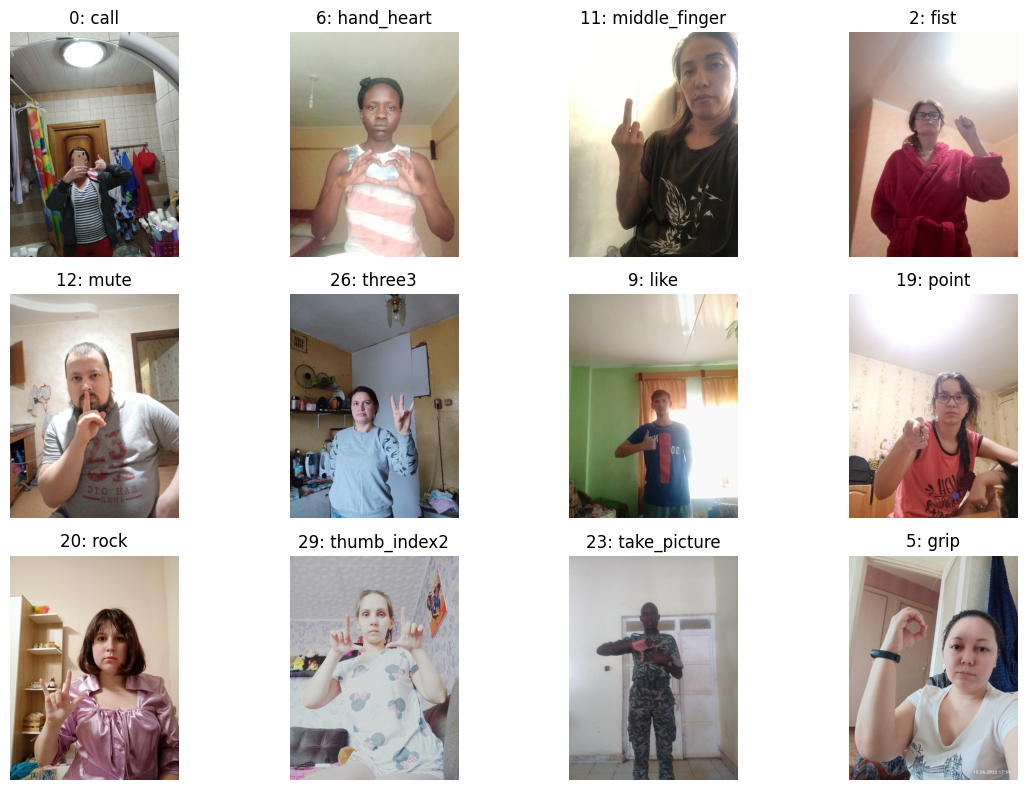

In [4]:
import matplotlib.pyplot as plt
import random

label_names = dataset.features["label"].names

idxs = random.sample(range(len(dataset)), 12)

plt.figure(figsize=(12, 8))

for plot_i, data_i in enumerate(idxs):
    sample = dataset[data_i]
    img = sample["image"]
    label = sample["label"]
    label_name = label_names[label]

    plt.subplot(3, 4, plot_i + 1)
    plt.imshow(img)
    plt.title(f"{label}: {label_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
target_names = ["fist", "like", "ok", "one", "palm"]

target_label_ids = {
    name: label_names.index(name)
    for name in target_names
    if name in label_names
}

print(target_label_ids)

{'fist': 2, 'like': 9, 'ok': 14, 'one': 15, 'palm': 16}


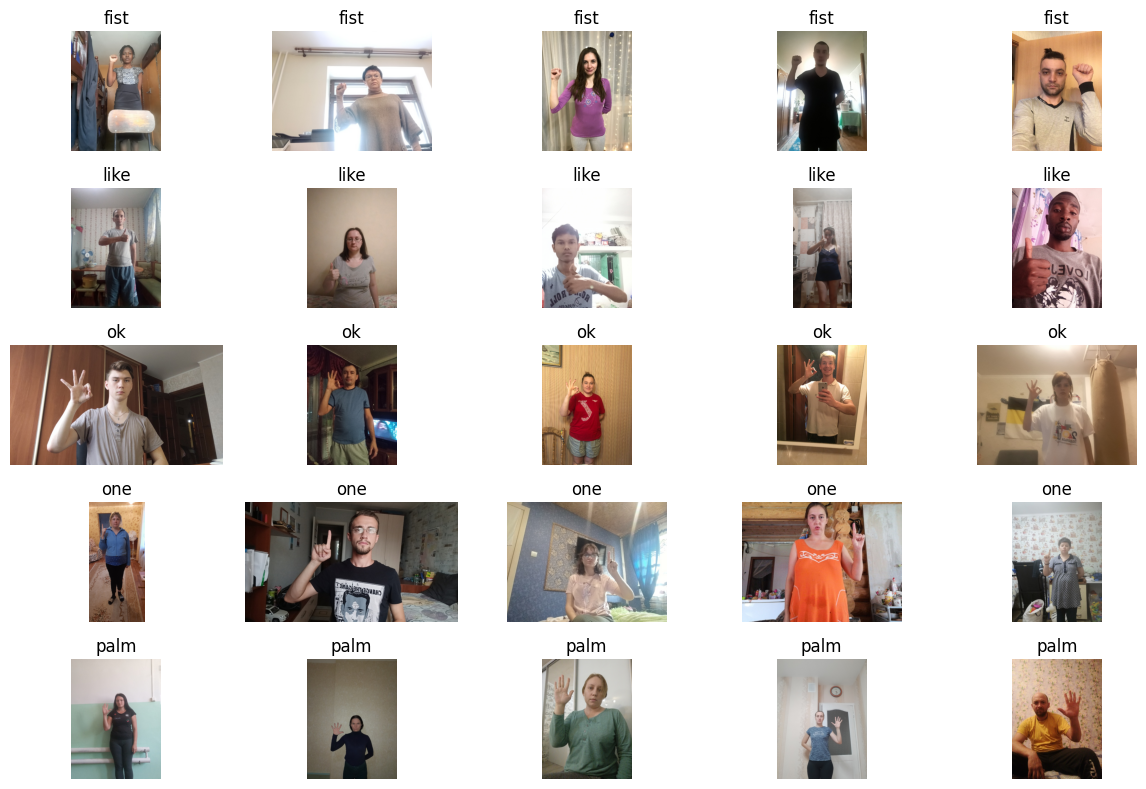

In [6]:
import matplotlib.pyplot as plt

target_names = ["fist", "like", "ok", "one", "palm"]
label_names = dataset.features["label"].names

labels = dataset["label"]   # 先只讀 label column，比一直 dataset[i] 快

target_indices = {}

for name in target_names:
    label_id = label_names.index(name)
    indices = [i for i, y in enumerate(labels) if y == label_id]
    target_indices[name] = indices[:5]

plt.figure(figsize=(12, 8))

plot_i = 1

for name in target_names:
    for idx in target_indices[name]:
        sample = dataset[idx]

        plt.subplot(5, 5, plot_i)
        plt.imshow(sample["image"])
        plt.title(name)
        plt.axis("off")

        plot_i += 1

plt.tight_layout()
plt.show()

## run preprocess

In [7]:
import sys
!{sys.executable} -m pip install -U mediapipe pillow tqdm matplotlib numpy pandas

In [8]:
from hand_preprocess import MediaPipeHandPreprocessor

preprocessor = MediaPipeHandPreprocessor()

idx: 5000
original label: fist
crop shape: (71, 62, 3)
landmarks shape: (21, 2)


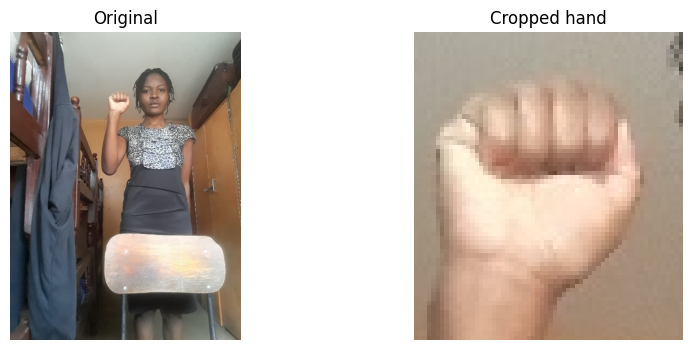

In [9]:
import matplotlib.pyplot as plt

label_names = dataset.features["label"].names
labels = dataset["label"]

target_name = "fist"
target_label = label_names.index(target_name)

idx = next(i for i, y in enumerate(labels) if y == target_label)

sample = dataset[idx]
img = sample["image"]

result = preprocessor.preprocess_image(img)

print("idx:", idx)
print("original label:", target_name)

if result is None:
    print("No hand detected")
else:
    crop, landmarks = result
    print("crop shape:", crop.shape)
    print("landmarks shape:", landmarks.shape)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(crop)
    plt.title("Cropped hand")
    plt.axis("off")

    plt.show()

In [10]:
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd
from tqdm import tqdm
import random

label_names = dataset.features["label"].names
labels = dataset["label"]

target_map = {
    "fist": 1,
    "like": 2,
    "ok": 3,
    "one": 4,
    "palm": 5,
}

target_names = list(target_map.keys())

out_dir = Path("D:/Hand_Gesture/data/processed_sample")
crop_dir = out_dir / "crops"
lm_dir = out_dir / "landmarks"

crop_dir.mkdir(parents=True, exist_ok=True)
lm_dir.mkdir(parents=True, exist_ok=True)

records = []

# target classes: each 20 images
selected_indices = []

for name in target_names:
    original_label_id = label_names.index(name)
    idxs = [i for i, y in enumerate(labels) if y == original_label_id]
    selected_indices += [(idx, target_map[name], name) for idx in idxs[:20]]

# N/A: non-target classes, sample 100 images
target_label_ids = {label_names.index(name) for name in target_names}
na_indices = [i for i, y in enumerate(labels) if y not in target_label_ids]

random.seed(0)
na_indices = random.sample(na_indices, 100)

selected_indices += [(idx, 0, "N_A") for idx in na_indices]

print("total selected:", len(selected_indices))

total selected: 200


In [11]:
fail_count = 0

for idx, new_label, new_label_name in tqdm(selected_indices):
    sample = dataset[idx]
    img = sample["image"]

    result = preprocessor.preprocess_image(img)

    if result is None:
        fail_count += 1
        continue

    crop, landmarks = result

    base_name = f"{idx}_{new_label_name}"

    crop_path = crop_dir / f"{base_name}.png"
    lm_path = lm_dir / f"{base_name}.npy"

    Image.fromarray(crop).save(crop_path)
    np.save(lm_path, landmarks)

    records.append({
        "idx": idx,
        "crop_path": str(crop_path),
        "landmark_path": str(lm_path),
        "label": new_label,
        "label_name": new_label_name,
    })

df = pd.DataFrame(records)
df.to_csv(out_dir / "labels.csv", index=False)

print("saved:", len(df))
print("failed:", fail_count)
print("labels.csv:", out_dir / "labels.csv")

100%|██████████| 200/200 [00:06<00:00, 31.61it/s]

saved: 188
failed: 12
labels.csv: D:\Hand_Gesture\data\processed_sample\labels.csv


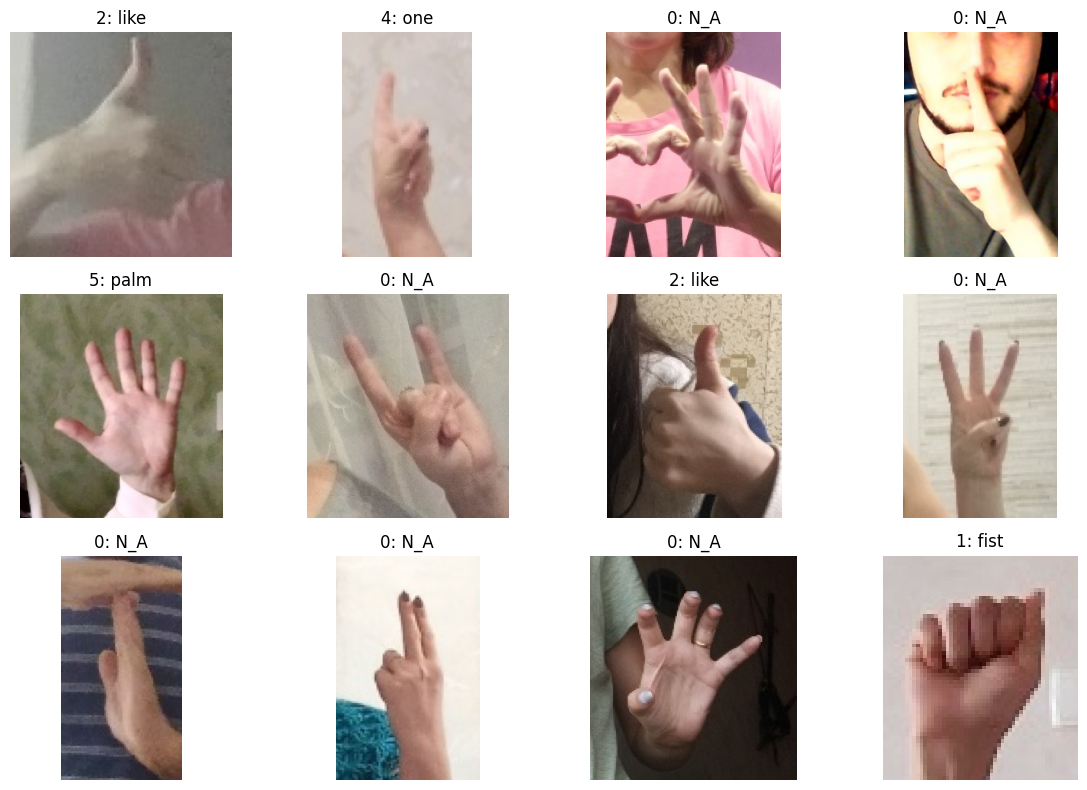

In [12]:
df = pd.read_csv("D:/Hand_Gesture/data/processed_sample/labels.csv")

show_df = df.sample(min(12, len(df)), random_state=1)

plt.figure(figsize=(12, 8))

for i, row in enumerate(show_df.itertuples()):
    img = Image.open(row.crop_path)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"{row.label}: {row.label_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
import pandas as pd
import numpy as np

df = pd.read_csv("D:/Hand_Gesture/data/processed_sample/labels.csv")

print(df.head())
print("total:", len(df))

row = df.iloc[0]
lm = np.load(row["landmark_path"])

print("landmark shape:", lm.shape)
print(lm[:5])

    idx                                          crop_path  \
0  5000  D:\Hand_Gesture\data\processed_sample\crops\50...   
1  5001  D:\Hand_Gesture\data\processed_sample\crops\50...   
2  5002  D:\Hand_Gesture\data\processed_sample\crops\50...   
3  5003  D:\Hand_Gesture\data\processed_sample\crops\50...   
4  5004  D:\Hand_Gesture\data\processed_sample\crops\50...   

                                       landmark_path  label label_name  
0  D:\Hand_Gesture\data\processed_sample\landmark...      1       fist  
1  D:\Hand_Gesture\data\processed_sample\landmark...      1       fist  
2  D:\Hand_Gesture\data\processed_sample\landmark...      1       fist  
3  D:\Hand_Gesture\data\processed_sample\landmark...      1       fist  
4  D:\Hand_Gesture\data\processed_sample\landmark...      1       fist  
total: 188
landmark shape: (21, 2)
[[0.34752113 0.80160415]
 [0.6167504  0.7043616 ]
 [0.75723463 0.55130285]
 [0.782737   0.41441217]
 [0.72709805 0.3067279 ]]


In [14]:
idx = selected_indices[0][0]
img = dataset[idx]["image"]

result = preprocessor.preprocess_image(img)

if result is None:
    print("No hand detected")
else:
    crop, landmarks = result
    print("ok")
    print(crop.shape)
    print(landmarks.shape)

ok
(71, 62, 3)
(21, 2)


## check suspicious

In [24]:
import numpy as np
import pandas as pd
from pathlib import Path

df = pd.read_csv("D:/Hand_Gesture/data/processed_sample/labels.csv")

def dist(a, b):
    return np.linalg.norm(a - b)

def get_finger_states(lm):
    """
    lm shape: (21, 2)
    return:
        thumb, index, middle, ring, pinky
        True = extended
        False = folded
    """
    wrist = lm[0]

    # palm scale，用來讓 threshold 不受 crop 大小影響
    palm_scale = dist(lm[0], lm[9]) + 1e-6

    # non-thumb fingers:
    # 如果 fingertip 比 PIP 更遠離 wrist，就大致視為伸直
    def is_extended(mcp, pip, dip, tip):
        return dist(lm[tip], wrist) > dist(lm[pip], wrist) + 0.15 * palm_scale

    index = is_extended(5, 6, 7, 8)
    middle = is_extended(9, 10, 11, 12)
    ring = is_extended(13, 14, 15, 16)
    pinky = is_extended(17, 18, 19, 20)

    # thumb 比較特別，用 thumb tip 離 palm center 的距離粗略判斷
    palm_center = (lm[0] + lm[5] + lm[9] + lm[13] + lm[17]) / 5
    thumb = dist(lm[4], palm_center) > 0.65 * palm_scale

    return {
        "thumb": thumb,
        "index": index,
        "middle": middle,
        "ring": ring,
        "pinky": pinky,
    }

def check_expected(label_name, lm):
    states = get_finger_states(lm)

    thumb = states["thumb"]
    index = states["index"]
    middle = states["middle"]
    ring = states["ring"]
    pinky = states["pinky"]

    extended_count = sum(states.values())

    # thumb tip 和 index tip 的距離，用來檢查 ok
    palm_scale = dist(lm[0], lm[9]) + 1e-6
    thumb_index_tip_dist = dist(lm[4], lm[8]) / palm_scale

    if label_name == "fist":
        # fist: 大部分手指應該是彎的
        ok = extended_count <= 1

    elif label_name == "like":
        # like: 拇指伸出，其他四指大多彎曲
        ok = thumb and (not index) and (not middle) and (not ring) and (not pinky)

    elif label_name == "one":
        # one: 食指伸出，其他大多彎曲
        ok = index and (not middle) and (not ring) and (not pinky)

    elif label_name == "palm":
        # palm: 至少四根手指伸出
        ok = extended_count >= 4

    elif label_name == "ok":
        # ok: 拇指尖和食指尖靠近
        # middle/ring/pinky 通常會伸出，但先不要設太嚴
        ok = thumb_index_tip_dist < 0.45

    else:
        # N/A 不檢查 target pattern
        ok = True

    return ok, states, thumb_index_tip_dist



In [ ]:
suspicious_records = []

for row in df.itertuples():
    label_name = row.label_name

    # 只檢查 target classes，N/A 先不檢查
    if label_name == "N_A":
        continue

    lm = np.load(row.landmark_path)

    ok, states, ok_dist = check_expected(label_name, lm)

    if not ok:
        suspicious_records.append({
            "idx": row.idx,
            "label": row.label,
            "label_name": label_name,
            "crop_path": row.crop_path,
            "landmark_path": row.landmark_path,
            "thumb": states["thumb"],
            "index": states["index"],
            "middle": states["middle"],
            "ring": states["ring"],
            "pinky": states["pinky"],
            "thumb_index_dist": ok_dist,
        })

suspicious_df = pd.DataFrame(suspicious_records)

print("total samples:", len(df))
print("suspicious target samples:", len(suspicious_df))

suspicious_df.head()

In [28]:
import numpy as np
import pandas as pd

df = pd.read_csv("D:/Hand_Gesture/data/processed_sample/labels.csv")

suspicious_records = []

for row in df.head(188).itertuples():
    label_name = row.label_name

    # 只檢查 target classes，N/A 先不檢查
    if label_name == "N_A":
        continue

    lm = np.load(row.landmark_path)

    ok, states, ok_dist = check_expected(label_name, lm)

    if not ok:
        suspicious_records.append({
            "idx": row.idx,
            "label": row.label,
            "label_name": label_name,
            "crop_path": row.crop_path,
            "landmark_path": row.landmark_path,
            "thumb": states["thumb"],
            "index": states["index"],
            "middle": states["middle"],
            "ring": states["ring"],
            "pinky": states["pinky"],
            "thumb_index_dist": ok_dist,
        })

suspicious_df = pd.DataFrame(suspicious_records)

print("checked rows:", len(df.head(5)))
print("suspicious found:", len(suspicious_df))
suspicious_df

checked rows: 5
suspicious found: 6


,idx,label,label_name,crop_path,landmark_path,thumb,index,middle,ring,pinky,thumb_index_dist
0,5012,1,fist,D:\Hand_Gesture\data\processed_sample\crops\50...,D:\Hand_Gesture\data\processed_sample\landmark...,True,True,True,True,True,3.260802
1,22509,2,like,D:\Hand_Gesture\data\processed_sample\crops\22...,D:\Hand_Gesture\data\processed_sample\landmark...,True,True,True,True,True,0.855440
2,22519,2,like,D:\Hand_Gesture\data\processed_sample\crops\22...,D:\Hand_Gesture\data\processed_sample\landmark...,True,True,True,True,True,4.387920
3,33965,3,ok,D:\Hand_Gesture\data\processed_sample\crops\33...,D:\Hand_Gesture\data\processed_sample\landmark...,True,False,True,True,True,0.543534
4,33970,3,ok,D:\Hand_Gesture\data\processed_sample\crops\33...,D:\Hand_Gesture\data\processed_sample\landmark...,True,True,True,False,False,0.570929
5,36478,4,one,D:\Hand_Gesture\data\processed_sample\crops\36...,D:\Hand_Gesture\data\processed_sample\landmark...,True,False,False,False,False,0.322495


# for 湘晴's preprocessed data

In [6]:
from pathlib import Path
import shutil
import pandas as pd

root_dir = Path("D:/Hand_Gesture/data/hagrid_set_v1_medium")
out_dir = Path("D:/Hand_Gesture/data/hagrid_set_v1_medium_processed")

crop_dir = out_dir / "crops"
landmark_dir = out_dir / "landmarks"

crop_dir.mkdir(parents=True, exist_ok=True)
landmark_dir.mkdir(parents=True, exist_ok=True)

label_map = {
    "N_A": 0,
    "fist": 1,
    "like": 2,
    "ok": 3,
    "one": 4,
    "palm": 5,
}

image_exts = [".png", ".jpg", ".jpeg", ".webp"]

def get_class_name(folder_name):
    name = folder_name.strip()

    # 先特別處理 NA 類
    if name in ["0_NA", "0_N_A", "NA", "N_A", "na", "n_a"]:
        return "N_A"

    # 處理 72_N_A / 72_NA / 100_fist 這種格式
    parts = name.split("_", 1)
    if len(parts) == 2 and parts[0].isdigit():
        name = parts[1]

    # 再處理一次 NA
    if name in ["NA", "N_A", "na", "n_a"]:
        return "N_A"

    return name.lower()

records = []
missing_landmarks = []
skipped_folders = []
copied_count = 0

for class_dir in root_dir.iterdir():
    if not class_dir.is_dir():
        continue

    folder_name = class_dir.name
    class_name = get_class_name(folder_name)

    if class_name not in label_map:
        skipped_folders.append(folder_name)
        continue

    label = label_map[class_name]

    for img_path in class_dir.iterdir():
        if img_path.suffix.lower() not in image_exts:
            continue

        # landmark 檔跟 image 同名，只是副檔名是 .npy
        lm_path = img_path.with_suffix(".npy")

        if not lm_path.exists():
            missing_landmarks.append(str(img_path))
            continue

        # 避免不同資料夾裡有同名檔案，所以加上 folder_name
        new_stem = f"{folder_name}_{img_path.stem}"

        new_img_path = crop_dir / f"{new_stem}{img_path.suffix.lower()}"
        new_lm_path = landmark_dir / f"{new_stem}.npy"

        shutil.copy2(img_path, new_img_path)
        shutil.copy2(lm_path, new_lm_path)

        records.append({
            "idx": img_path.stem,
            "original_class_folder": folder_name,
            "label": label,
            "label_name": class_name,
            "crop_path": str(new_img_path),
            "landmark_path": str(new_lm_path),
            "quality": "ok"
        })

        copied_count += 1

df = pd.DataFrame(records)

csv_path = out_dir / "labels.csv"
df.to_csv(csv_path, index=False)

print("Done.")
print("Copied samples:", copied_count)
print("Saved labels.csv to:", csv_path)

print("\nClass counts:")
print(df["label_name"].value_counts())

print("\nSkipped folders:")
print(skipped_folders)

print("\nMissing landmark files:", len(missing_landmarks))
if len(missing_landmarks) > 0:
    print("First 10 missing:")
    for x in missing_landmarks[:10]:
        print(x)

Done.
Copied samples: 9988
Saved labels.csv to: D:\Hand_Gesture\data\hagrid_set_v1_medium_processed\labels.csv

Class counts:
label_name
N_A     4988
fist    1000
like    1000
ok      1000
one     1000
palm    1000
Name: count, dtype: int64

Skipped folders:
[]

Missing landmark files: 0
